In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 


In [2]:
df = pd.read_csv("/home/sanskar/DEEP_LEARNING/ANN_PROJECTS/Admission_Predict.csv")

In [3]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [4]:
df.shape

(400, 9)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
# Drop the Serial No. column 
df = df.drop(columns=["Serial No."])

In [8]:
df.shape

(400, 8)

In [11]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]


In [12]:
y

0      0.92
1      0.76
2      0.72
3      0.80
4      0.65
       ... 
395    0.82
396    0.84
397    0.91
398    0.67
399    0.95
Name: Chance of Admit , Length: 400, dtype: float64

In [19]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 1)

In [20]:
X_train

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
93,301,97,2,3.0,3.0,7.88,1
23,334,119,5,5.0,4.5,9.70,1
299,305,112,3,3.0,3.5,8.65,0
13,307,109,3,4.0,3.0,8.00,1
90,318,106,2,4.0,4.0,7.92,1
...,...,...,...,...,...,...,...
255,307,110,4,4.0,4.5,8.37,0
72,321,111,5,5.0,5.0,9.45,1
396,325,107,3,3.0,3.5,9.11,1
235,326,111,5,4.5,4.0,9.23,1


In [22]:
from sklearn.preprocessing import MinMaxScaler 
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
import tensorflow
from tensorflow import keras 
from keras import Sequential 
from keras.layers import Dense

In [26]:
model = Sequential()

model.add(Dense(7, activation="relu", input_dim = 7))
model.add(Dense(1, activation="linear"))

/home/sanskar/jupyter-env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1783515799.707034   14357 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [27]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64 (256.00 B)

 Trainable params: 64 (256.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.compile(loss = "mean_squared_error", optimizer="Adam")

In [32]:
history = model.fit(X_train_scaled, y_train, epochs=1000, validation_split =0.2)

Epoch 1/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.6191 - val_loss: 0.6586
Epoch 2/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.5411 - val_loss: 0.5765
Epoch 3/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.4708 - val_loss: 0.5023
Epoch 4/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4084 - val_loss: 0.4358
Epoch 5/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3512 - val_loss: 0.3780
Epoch 6/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3032 - val_loss: 0.3264
Epoch 7/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2607 - val_loss: 0.2812
Epoch 8/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2237 - val_loss: 0.2419
Epoch 9/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1912 - val_loss: 0.2083
Epoch 10/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1635 - val_loss: 0.1794
Epoch 11/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1403 - val_loss: 0.1547
Epoch 12/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1

In [33]:
y_pred = model.predict(X_test_scaled)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [34]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.8142016699383187

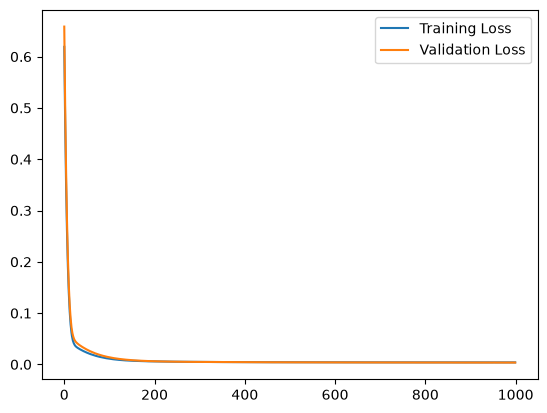

In [39]:
plt.plot(history.history["loss"], label= "Training Loss",)
plt.plot(history.history["val_loss"], label = "Validation Loss")
plt.legend()